# ✅ Logistic Regression , k-NN, SVM, Decision Tree, Ensamble 모델을 이용한 분류문제

- 다양한 모델을 반복문으로 한 번에 처리할 수 있도록 리스트에 모델들을 담아 순회하는 방식으로 코드를 작성.

- Scikit-learn의 Pipeline은 '스케일러 + 모델 A'처럼 하나의 흐름을 정의하고,
- 리스트에 각 모델 객체(혹은 파이프라인 객체)를 담아 루프를 돌리는 방식.

  - 중복 제거: 스케일러 정의와 학습(fit), 예측(predict) 과정을 모델마다 따로 적지 않고 for 루프 하나로 묶어 코드 양을 줄이기.

  - 유연한 확장성: 나중에 서포트 벡터 머신(SVM)이나 결정 트리(Decision Tree) 같은 새로운 분류 모델을 추가하고 싶다면, models 리스트에 추가

  - 조건부 속성 접근: k-NN 알고리즘에는 가중치(w)나 절편(b) 개념이 없으므로, if 조건문을 활용해 로지스틱 회귀일 때만 해당 속성을 출력하도록 예외 처리를 하기


# ✅  [분류문제 웹서비스 배포]
- 다양한 분류 모델를 웹에서 직접 확인하고 테스트할 수 있도록 Streamlit 애플리케이션으로 전환하고, pyngrok을 이용해 외부에서 접속 가능한 임시 URL로 배포하는 전체 과정

- 요구사항
  - 모델 및 기준값을 파일(.pkl)로 저장 및 로드,
  - %%writefile app.py 웹 소스 활용,
  - 구글 코랩 환경을 고려한 ngrok 터널링 최적화을 반영

### 1 단계: 필수 라이브러리 설치


In [2]:
# Streamlit과 ngrok 설치
!pip install streamlit -q
!pip install pyngrok -q



### 2단계: 모델 학습 및 파일(.pkl) 저장
- 데이터를 준비 및 통합
  - 닥스훈트와 진돗개의 길이·높이 데이터를 생성하고 하나의 데이터셋으로 통합,
- 파이프라인 모델들을 학습시킨 뒤
- joblib 라이브러리를 사용하여 저장.



In [ ]:
# 필수 라이브러리 설치 (Streamlit, pyngrok, joblib)
import numpy as np
import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler




# ==========================================
# 1. 데이터 준비 및 통합
# ==========================================
# 1. 원본 데이터 정의 (닥스훈트: 0, 진돗개: 1)
dach_length = [55, 57, 64, 63, 58, 49, 54, 61]
dach_height = [30, 31, 36, 30, 33, 25, 37, 34]
jin_length = [56, 47, 56, 46, 49, 53, 52, 48]
jin_height = [52, 52, 50, 53, 50, 53, 49, 54]

# 2. 데이터 변환 및 레이블링



# 3. 훈련 데이터 병합



# ===================================================
# 2. 모델 딕셔너리 정의 (로지스틱 회귀, k-NN, SVM 등 )
# ===================================================
# 사용할 모델들을 이름과 파이프라인 함께 사전으로 묶기.







# ==========================================
# 3. 루프를 통한 파이프라인 모델 일괄 실행
# ==========================================




# 4. 모델 및 기준값을 하나의 딕셔너리로 묶어 파일로 저장



joblib.dump(payload, "dog_classifier_models.pkl")
print("✅ 모델 파이프라인이 'dog_classifier_models.pkl'로 성공적으로 저장되었습니다!")



### 3 단계: Streamlit 앱 파일 생성 (%%writefile app.py)
- 파일(.pkl)을 읽어와 화면에 결과를 띄워주는 app.py 웹 애플리케이션 코드 생성.

In [ ]:
%%writefile app.py
import streamlit as st
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(page_title="견종 분류 파이프라인 시스템", layout="centered")

# 1. 저장된 pkl 데이터 로드
def load_saved_data():
    return joblib.load("dog_classifier_models.pkl")

data = load_saved_data()
models = data["models"]
dog_classes = data["dog_classes"]
X_data = data["y_data"]

st.title("파이프라인 기반 견종(닥스훈트/진돗개) 분류기")
st.markdown("로지스틱 회귀, k-NN, 그리고 **SVM 모델**의 예측 결과를 실시간으로 비교하고 테스트합니다.")

# 사이드바 설정 - 모델 선택 및 특성 입력
st.sidebar.header("모델 선택 및 데이터 입력")
selected_model_name = st.sidebar.selectbox("예측에 사용할 모델을 선택하세요:", list(models.keys()))
current_pipeline = models[selected_model_name]

st.sidebar.subheader("개의 신체 수치 조절")
input_length = st.sidebar.slider("몸 길이 (Length, cm)", 40, 70, 55)
input_height = st.sidebar.slider("몸 높이 (Height, cm)", 20, 60, 35)

# 예측할 데이터 포맷 구성
new_data = np.array([[input_length, input_height]])

st.subheader(f"선택된 모델: {selected_model_name}")

# 2. 실시간 분류 예측 수행





# 3. 확률 예측 지원 모델일 경우 예측 확률 시각화:




    st.write("### 📈 모델의 견종별 예측 확률")
    st.bar_chart(proba_df.set_index('견종'))

# 4. 최종 진단 결과 리포트 출력
st.markdown("---")
if pred_class_idx == 0:
    st.success(f"결과: 이 개는 **{pred_label}**로 예측됩니다! (특징: 다리가 짧고 몸이 김)")
else:
    st.info(f"결과: 이 개는 **{pred_label}**로 예측됩니다! (특징: 다리가 길고 다부진 체형)")

st.caption("Tip: 파이프라인 내부에 `StandardScaler`가 내장되어 있어 수동 전처리 없이 원본 수치 그대로 실시간 예측이 가능합니다.")


### 4 단계: ngrok을 이용한 실시간 웹 배포 및 구동 코드


In [ ]:
# 기존 코드를 멈추고, 아래 코드로 다시 실행.
!pip install streamlit pyngrok -q
from pyngrok import ngrok
import os
import time

# 1. 혹시 열려있을지 모르는 기존 터널 모두 닫기
ngrok.kill()

# 2. 인증 토큰 설정
ngrok.set_auth_token("토큰입력")

# 3. Streamlit 실행 (서버 주소를 명시적으로 127.0.0.1로 고정하여 백그라운드 구동)
os.system("nohup streamlit run app.py --server.address 127.0.0.1 --server.port 8501 > /dev/null 2>&1 &")

# Streamlit 서버가 완전히 부팅될 때까지 3초간 대기
time.sleep(3)

# 4. ngrok 터널 연결 (8501 포트 열기)
public_url = ngrok.connect(8501, bind_tls=True)

print("=" * 60)
print(f"성공적으로 배포되었습니다! 아래 링크를 클릭하세요:\n{public_url}")
print("=" * 60)

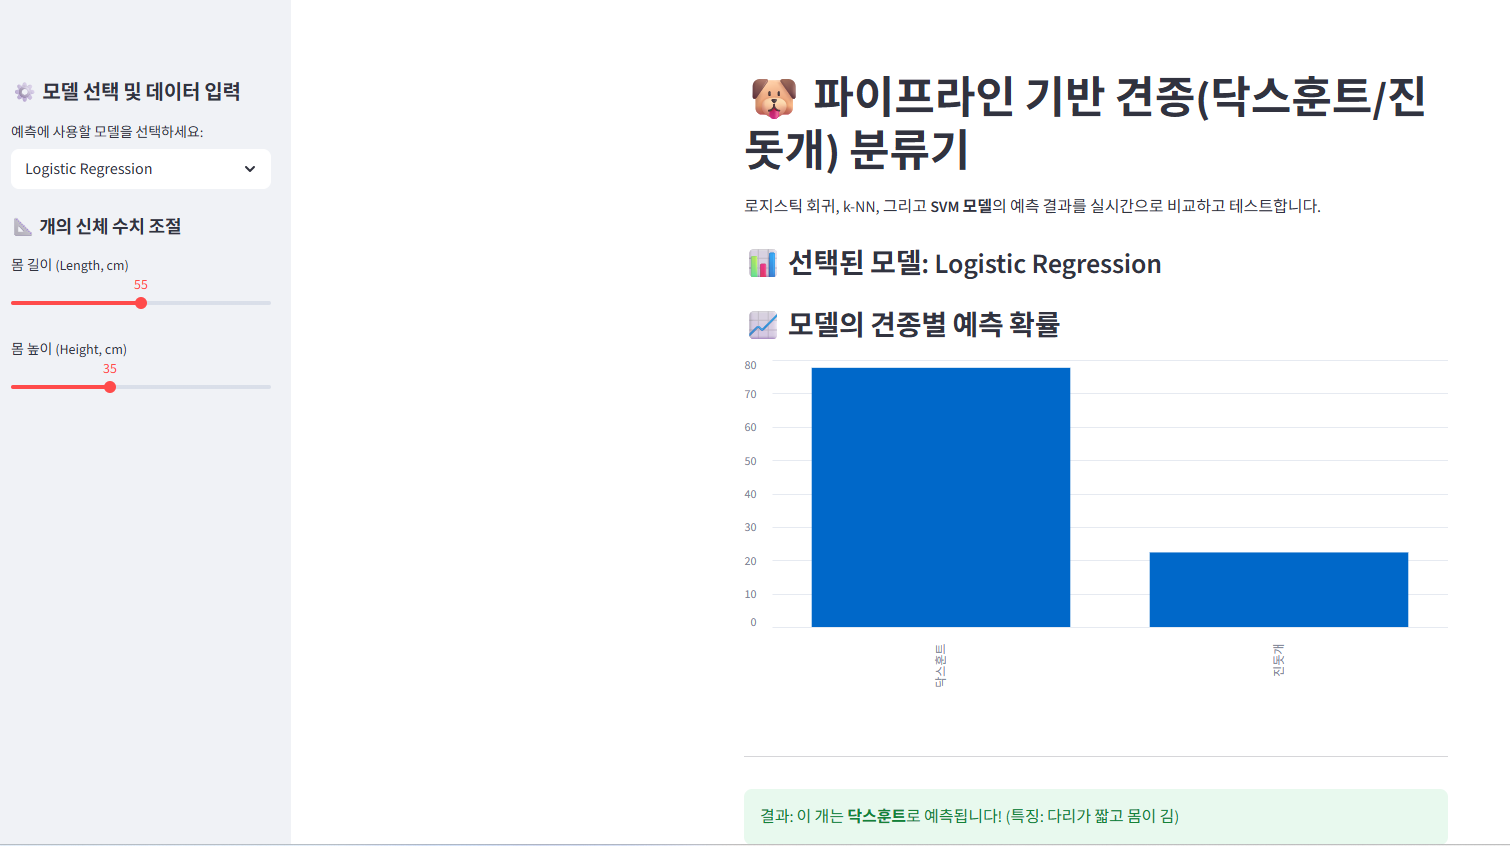

## ✅  모델 성능 비교

- Scikit-learn에서 제공하는 위스콘신 유방암 데이터셋(Breast Cancer Dataset)을 활용
- 4가지 모델(로지스틱 회귀, SVM, 결정 트리, 앙상블)을 각각 파이프라인(Pipeline) 구조로 구축하고 성능을 비교.

- 의료 데이터 특성상 단순 정확도(Accuracy)뿐만 아니라
- 암 환자를 놓치지 않는 재현율(Recall)이 중요하므로, 평가지표 출력 및 혼동 행렬(Confusion Matrix) 시각화.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 모델 불러오기
from sklearn.linear_model import LogisticRegression

# 평가 지표 불러오기


# 1. 데이터 로드 및 분할




# 2. 파이프라인 구축



# 3. 모델 학습, 예측 및 평가지표 출력


print("\n[상세 분류 리포트 (Classification Report)]")


# 4. 혼동 행렬(Confusion Matrix) 시각화
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, matrix) in enumerate(confusion_matrices.items()):
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=cancer.target_names, yticklabels=cancer.target_names, ax=axes[idx])
    axes[idx].set_title(f"{name}\nAccuracy: {results[name]:.4f}")
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")

plt.tight_layout()
plt.show()